<a href="https://colab.research.google.com/github/KutyshenkoYana/ITStep-AI/blob/superwised_learning/SL_HomeWork_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Дані

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/ITStep-AI/refs/heads/superwised_learning/data/customer_spending.csv")

In [3]:
df.head()

,annual_income,account_tenure_days,age,engagement_score,support_tickets,annual_spending
0,57964.98,1170,65,35.95,5,218.46
1,27667.36,856,58,14.56,2,16.51
2,74068.69,1178,31,33.26,2,240.06
3,82232.89,741,33,87.93,2,242.77
4,16763.02,497,31,10.22,0,130.61


# Опис даних

Цу дані користувачів онлайн-сервісу **Shoply** — сайту, де люди купують товари та оформлюють підписки. Для кожного користувача зібрана інформація про його активність, дохід та взаємодію із сайтом.

* **annual_income** — скільки грошей користувач заробляє за рік
* **account_tenure_days** — скільки днів користувач зареєстрований на сайті
* **age** — вік користувача
* **engagement_score** — наскільки активно користувач користується сайтом
* **support_tickets** — скільки разів користувач звертався до служби підтримки
* **annual_spending** — скільки грошей користувач витрачає на сайті за рік


Потрібно спрогнозувати **витрати** користувача

# Завдання 1
Розділіть дані на ознаки для моделі(Х) та цільову змінну(y)

In [4]:
X = df.drop(columns=["annual_spending"])
y = df["annual_spending"]

# Завдання 2
Розділіть дані на тренувальну та тестову вибірку

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Завдання 3
Нетренуйте дерево рішень на тренувальній вибірці

При створенні моделі використовуйте параметри за замовчуванням

In [6]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(X_train, y_train)

DecisionTreeRegressor()

# Завдання 4
Спронозуйте витрати користувача для тренувальних даних та порівняйте зі справжніми

Використайте метрики MAE, MSE, R2

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_train_pred = model.predict(X_train)

print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("MSE:", mean_squared_error(y_train, y_train_pred))
print("R2:", r2_score(y_train, y_train_pred))

MAE: 0.0
MSE: 0.0
R2: 1.0


# Завдання 5
Спронозуйте витрати користувача для тестових даних та порівняйте зі справжніми

Використайте метрики MAE, MSE, R2

In [8]:
y_test_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("MSE:", mean_squared_error(y_test, y_test_pred))
print("R2:", r2_score(y_test, y_test_pred))

MAE: 33.210023006134975
MSE: 1741.7940213957054
R2: 0.5060151331927172


# Завдання 6
Для різних значень параметра `max_depth` натренуйте модель та порахуйте метрику `MAE` на тренувальних та тестових даних

Отримайте відповідно 2 списки -- `train_mae` та `test_mae`
візуалізуйте їх

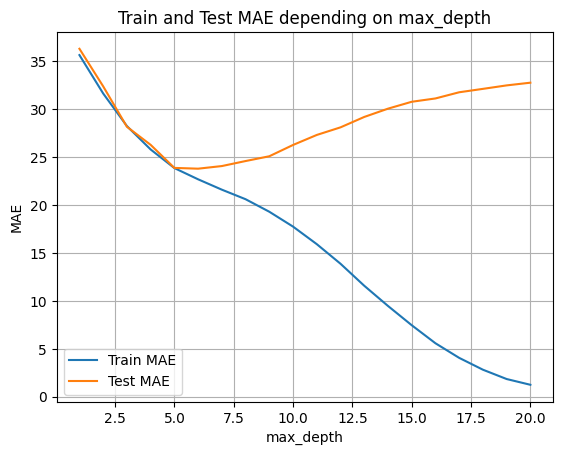

In [9]:
import matplotlib.pyplot as plt

max_depths = range(1, 21)
train_mae = []
test_mae = []

for depth in max_depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_mae.append(mean_absolute_error(y_train, train_pred))
    test_mae.append(mean_absolute_error(y_test, test_pred))

plt.plot(max_depths, train_mae, label="Train MAE")
plt.plot(max_depths, test_mae, label="Test MAE")

plt.xlabel("max_depth")
plt.ylabel("MAE")
plt.title("Train and Test MAE depending on max_depth")
plt.legend()
plt.grid()

plt.show()

In [ ]:
# код для візуалізації
# вам потрібно створити список max_depthes зі значеннями параметра який ви використовували
import matplotlib.pyplot as plt

plt.plot(max_depths, train_mae, label="Train MAE")
plt.plot(max_depths, test_mae, label="Test MAE")

plt.xlabel("max_depth")
plt.ylabel("MAE")
plt.title("Train and Test MAE depending on max_depth")
plt.legend()
plt.grid()

plt.show()

# Завдання 7
По графіку визначте оптимальне значення параметра `max_depth`

In [10]:
optimal_depth = max_depths[test_mae.index(min(test_mae))]
print("Optimal max_depth:", optimal_depth)

Optimal max_depth: 6
